In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn

print("dataset berhasil dimuat!")
ds = pd.read_csv("dataset_murid_g3.csv", sep=";")

ds.head()

dataset berhasil dimuat!


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,74,68,72
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,63,68,61
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,77,74,79
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,92,76,88
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,61,43,41


In [99]:
ds.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [100]:
ds.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,64.605547,55.585516,59.476117
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,17.212677,16.651544,17.279469
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,7.000000,7.000000,8.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,52.000000,44.000000,47.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,65.000000,56.000000,60.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,76.000000,67.000000,70.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,100.000000,100.000000,100.000000


In [101]:
ds.shape

(649, 33)

In [102]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [103]:
ds.duplicated().sum()

np.int64(0)

In [104]:
korelasi = ds.corr(numeric_only=True)

korelasi["G3"].sort_values(ascending=False)

G3            1.000000
G2            0.934063
G1            0.925751
absences      0.073480
age           0.058655
failures      0.036950
famrel        0.019196
goout         0.009561
freetime      0.004528
traveltime    0.004451
studytime    -0.004476
Walc         -0.011032
Dalc         -0.031984
health       -0.040799
Fedu         -0.081499
Medu         -0.085725
Name: G3, dtype: float64

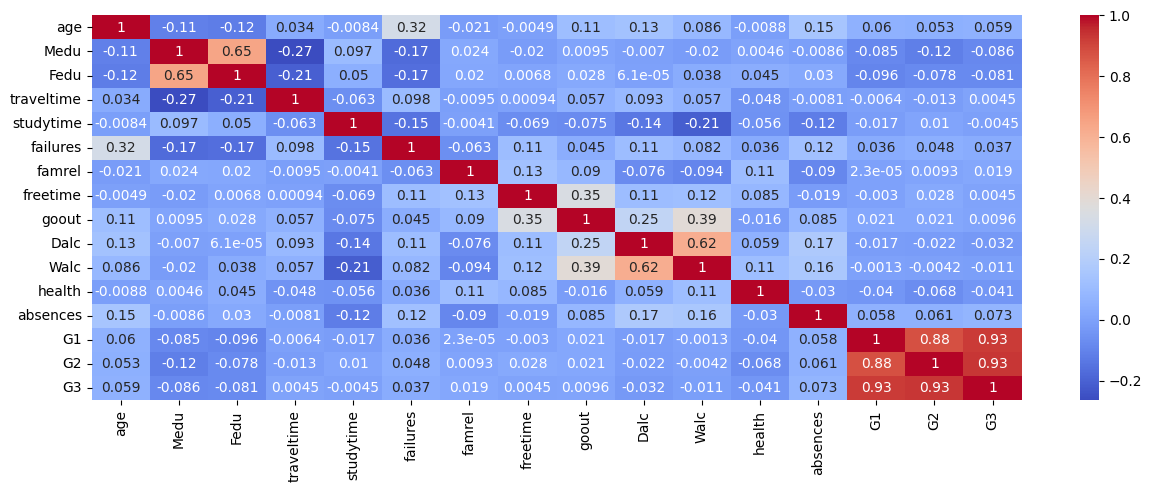

In [105]:
##visualisasi korelasi
plt.figure(figsize=(15, 5))

sns.heatmap(
    korelasi,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [106]:
from sklearn.preprocessing import LabelEncoder

print("dataset sebelum di encoding:")
ds = pd.read_csv("dataset_murid_g3.csv", sep=";")
print(ds.head(10))

print("dataset setelah di encoding:")
le = LabelEncoder()
for kolom in ds.select_dtypes(include="object").columns:
    ds[kolom] = le.fit_transform(ds[kolom])

print(ds.head(10))

dataset sebelum di encoding:
  school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0     GP   F   18       U     GT3       A     4     4   at_home   teacher   
1     GP   F   17       U     GT3       T     1     1   at_home     other   
2     GP   F   15       U     LE3       T     1     1   at_home     other   
3     GP   F   15       U     GT3       T     4     2    health  services   
4     GP   F   16       U     GT3       T     3     3     other     other   
5     GP   M   16       U     LE3       T     4     3  services     other   
6     GP   M   16       U     LE3       T     2     2     other     other   
7     GP   F   17       U     GT3       A     4     4     other   teacher   
8     GP   M   15       U     LE3       A     3     2  services     other   
9     GP   M   15       U     GT3       T     3     4     other     other   

   ... famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0  ...      4        3      4     1     1      3   

sex
0    383
1    266
Name: count, dtype: int64


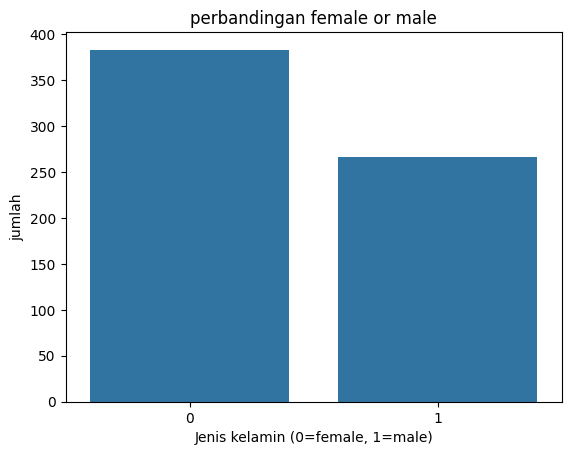

In [107]:
print(ds["sex"].value_counts())

sns.countplot(x="sex", data=ds)
plt.title("perbandingan female or male")
plt.xlabel("Jenis kelamin (0=female, 1=male)")
plt.ylabel("jumlah")
plt.show()

In [108]:
x = ds.drop("G3", axis=1)
y = ds["G3"]

In [109]:
#pilih 10 fitur terbaik menggunakan 3 method
#filter method
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

print("Fitur selection dengan filter method:")
filter = SelectKBest(
    score_func=f_regression,
    k=10
)

filter.fit(x, y)

filter_features = x.columns[
    filter.get_support()
]


print(filter_features)

Fitur selection dengan filter method:
Index(['school', 'age', 'Medu', 'Fedu', 'Mjob', 'famsup', 'higher', 'absences',
       'G1', 'G2'],
      dtype='object')


In [110]:
#wrapper method
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

print("Fitur selection dengan wrapped method:")
wrapper = RFE(
    estimator=RandomForestRegressor(
        random_state=42,
        n_estimators=100
    ),
    n_features_to_select=10
)

wrapper.fit(x, y)

wrapper_feature = x.columns[
    wrapper.get_support()
]

print(wrapper_feature)

Fitur selection dengan wrapped method:
Index(['age', 'Medu', 'Mjob', 'freetime', 'goout', 'Walc', 'health',
       'absences', 'G1', 'G2'],
      dtype='object')


In [111]:
#embedded method 
print("Fitur selection menggunakan embedded method:")
from sklearn.ensemble import RandomForestRegressor

embedded = RandomForestRegressor(random_state=42)

embedded.fit(x, y)

importance = embedded.feature_importances_

hasil = pd.DataFrame({
    "Fitur": x.columns,
    "Importance": importance
})

hasil = hasil.sort_values(
    by="Importance",
    ascending=False
)

embedded_feature = hasil["Fitur"].head(10)

print(embedded_feature)

Fitur selection menggunakan embedded method:
31          G2
30          G1
29    absences
27        Walc
28      health
8         Mjob
25       goout
24    freetime
2          age
9         Fjob
Name: Fitur, dtype: object


In [112]:
## membuat fungsi untuk menghitung akurasi method
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

def eval_fitur(fitur):
    x_selected = ds[fitur]

    x_train, x_test, y_train, y_test = train_test_split(
        x_selected,
        y,
        train_size=0.8,
        random_state=42
    )

    model = RandomForestRegressor()
    model.fit(x_train, y_train)

    prediksi = model.predict(x_test)

    return r2_score(y_test, prediksi)

In [113]:
##hasil hitungan dari akurasi method
r2_filter = eval_fitur(filter_features)
r2_wrapper = eval_fitur(wrapper_feature)
r2_embedded = eval_fitur(embedded_feature)

hasil_akurasi = pd.DataFrame({
    "Method":[
        "Filter",
        "Wrapper",
        "Embedded"
    ],

    "R2_score":[
        r2_filter,
        r2_wrapper,
        r2_embedded
    ]
})

hasil_akurasi = hasil_akurasi.sort_values(
    by="R2_score",
    ascending=False
)

print(hasil_akurasi)

     Method  R2_score
1   Wrapper  0.877182
2  Embedded  0.870064
0    Filter  0.868651


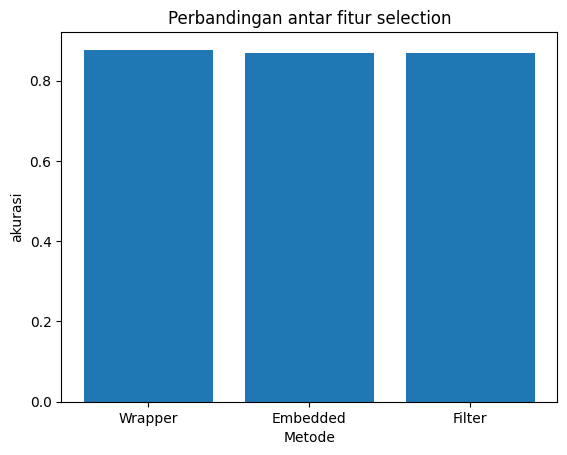

In [114]:
##visulisasi perbandingan akurasi fitur selection

plt.Figure(figsize=(10, 5))
plt.bar(
    hasil_akurasi["Method"],
    hasil_akurasi["R2_score"]
)


plt.title("Perbandingan antar fitur selection")
plt.xlabel("Metode")
plt.ylabel("akurasi")
plt.show()

In [115]:
x_final= ds[wrapper_feature]
y_final= ds["G3"]

print(f"Fitur sebelum dipangkas menjadi 10:", ds.shape)
print(f"Fitur setelah dipangkas menjadi 10:", ds[wrapper_feature].shape)

Fitur sebelum dipangkas menjadi 10: (649, 33)
Fitur setelah dipangkas menjadi 10: (649, 10)


In [116]:
#latih model Random forest regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_final,
    y_final,
    train_size=0.8,
    random_state=42
)

print(f"Jumlah data latih:", x_train.shape)
print(f"Jumlah data test:", x_test.shape)

model_final = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_final.fit(x_train, y_train)

Jumlah data latih: (519, 10)
Jumlah data test: (130, 10)


RandomForestRegressor(random_state=42)

In [117]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

prediksi = model_final.predict(x_test)

mae = mean_absolute_error(y_test, prediksi)
mse = mean_squared_error(y_test, prediksi)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, prediksi)

print(f"Jumlah mae: {mae:.4f}")
print(f"Jumlah mse: {mse:.4f}")
print(f"Jumlah rmse: {rmse:.4f}")
print(f"Jumlah r2: {r2:.4f}")

Jumlah mae: 4.7955
Jumlah mse: 34.1409
Jumlah rmse: 5.8430
Jumlah r2: 0.8764


In [118]:
import joblib

joblib.dump(model_final, 'model-student.pkl')
print("Model berhasil disimpan menjadi 'model-student.pkl'")

Model berhasil disimpan menjadi 'model-student.pkl'
